# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Student Performance Dataset](https://www.kaggle.com/datasets/shambhurajejagadale/student-performance-prediction-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.	

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('student_dataset_10000_rows.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


## last Five row

In [4]:
df.tail()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
9995,2,58,9,7,8,88,69.31,Not Placed
9996,7,98,6,9,4,87,100.00,Placed
9997,10,44,8,5,10,37,95.94,Placed
9998,10,75,7,5,8,52,88.61,Placed
9999,2,70,6,11,16,52,78.96,Placed


## Shape of our dataset

In [5]:
df.shape

(10000, 8)

## List out all columns

In [6]:
df.columns

Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score',
       'placement_status'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

study_hours                int64
attendance                 int64
sleep_hours                int64
internet_usage             int64
assignments_completed      int64
previous_score             int64
exam_score               float64
placement_status          object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB


## Check Null Value

In [9]:
df.isnull().sum()

study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.989600,69.88460,6.498500,6.062600,9.988400,64.91100,86.704207
std,3.163589,17.61653,1.709354,3.138163,6.034145,17.50302,15.058383
min,1.000000,40.00000,4.000000,1.000000,0.000000,35.00000,26.670000
25%,3.000000,55.00000,5.000000,3.000000,5.000000,50.00000,76.727500
50%,6.000000,70.00000,6.500000,6.000000,10.000000,65.00000,92.120000
75%,9.000000,85.00000,8.000000,9.000000,15.000000,80.00000,100.000000
max,11.000000,100.00000,9.000000,11.000000,20.000000,95.00000,100.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

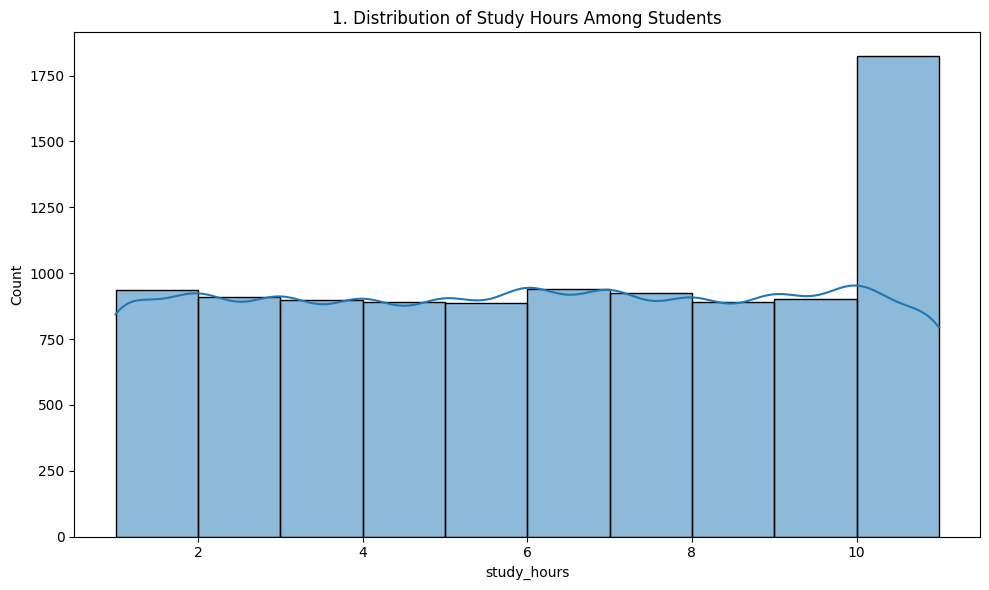

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['study_hours'], bins=10, kde=True)
plt.title(f'{plot_no}. Distribution of Study Hours Among Students')
show_fig()
plot_no += 1

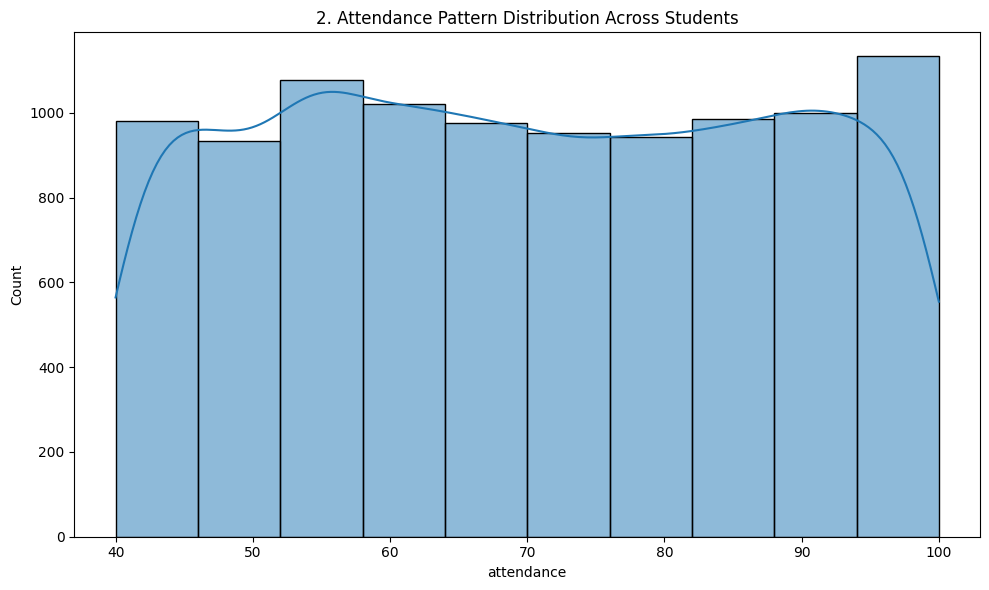

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['attendance'], bins=10, kde=True)
plt.title(f'{plot_no}. Attendance Pattern Distribution Across Students')
show_fig()
plot_no += 1

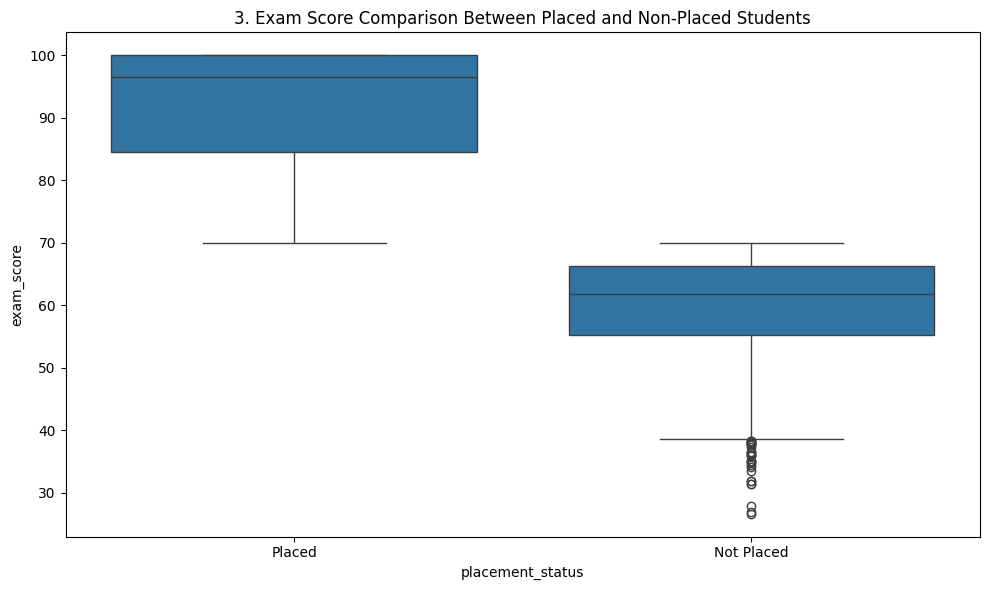

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='placement_status', y='exam_score', data=df)
plt.title(f'{plot_no}. Exam Score Comparison Between Placed and Non-Placed Students')
show_fig()
plot_no += 1

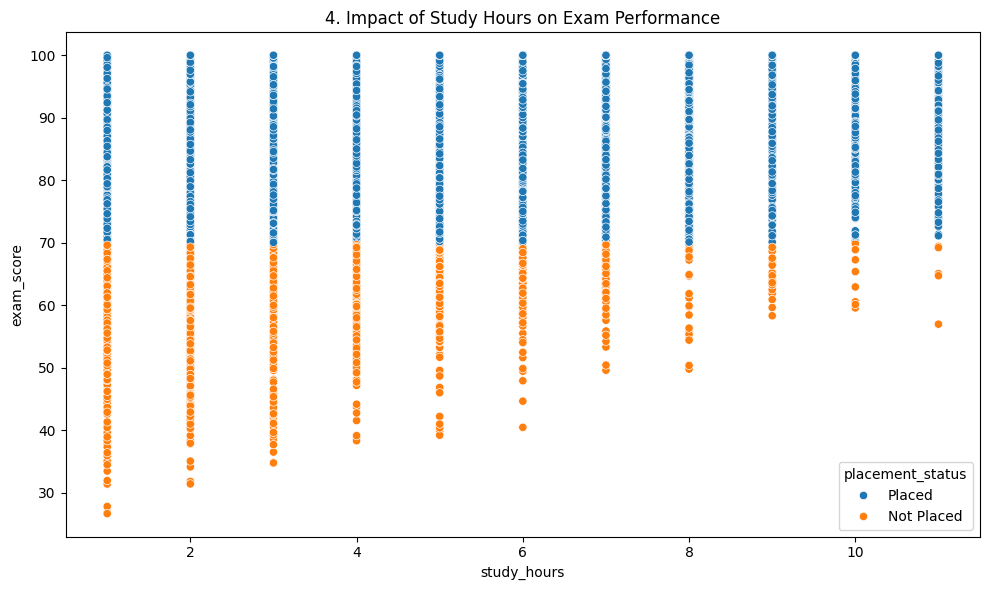

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='study_hours', y='exam_score', hue='placement_status', data=df)
plt.title(f'{plot_no}. Impact of Study Hours on Exam Performance')
show_fig()
plot_no += 1

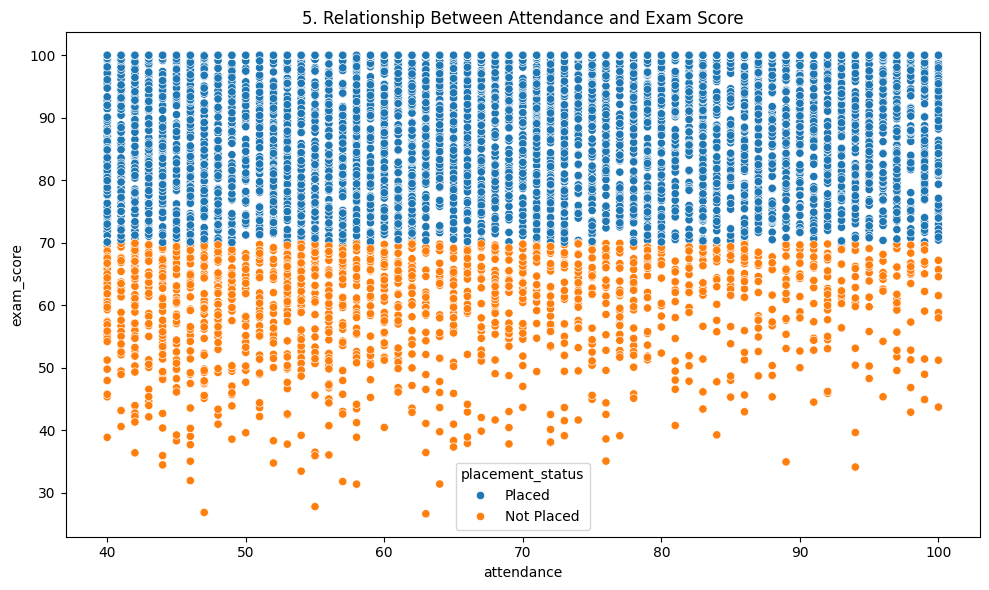

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='attendance', y='exam_score', hue='placement_status', data=df)
plt.title(f'{plot_no}. Relationship Between Attendance and Exam Score')
show_fig()
plot_no += 1

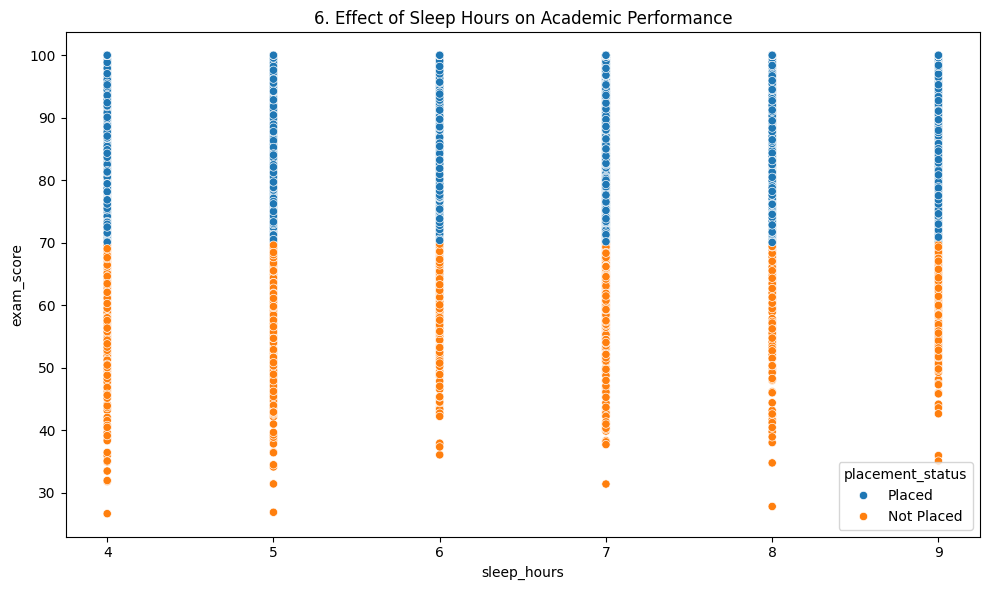

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='sleep_hours', y='exam_score', hue='placement_status', data=df)
plt.title(f'{plot_no}. Effect of Sleep Hours on Academic Performance')
show_fig()
plot_no += 1

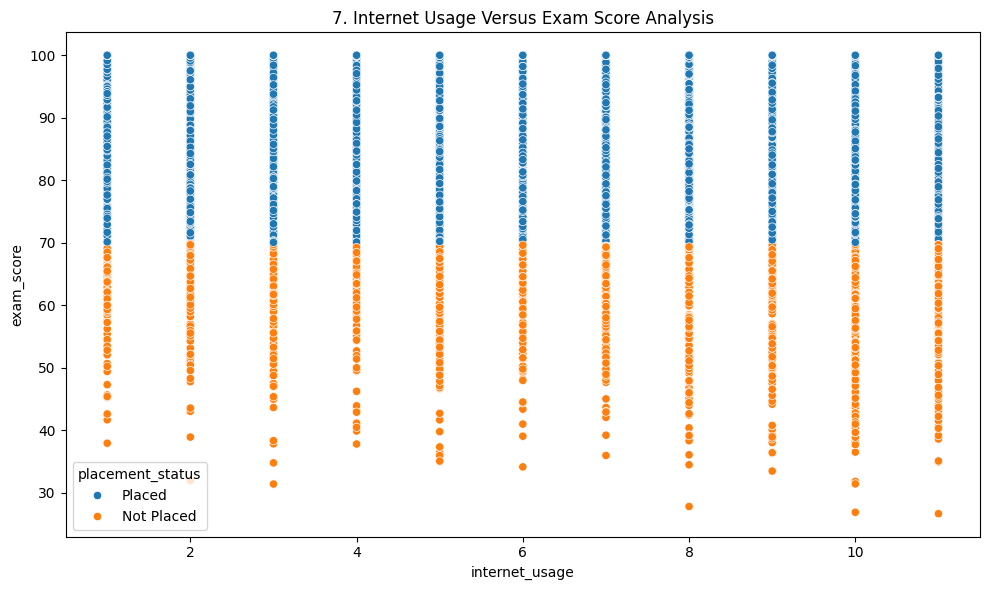

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='internet_usage', y='exam_score', hue='placement_status', data=df)
plt.title(f'{plot_no}. Internet Usage Versus Exam Score Analysis')
show_fig()
plot_no += 1

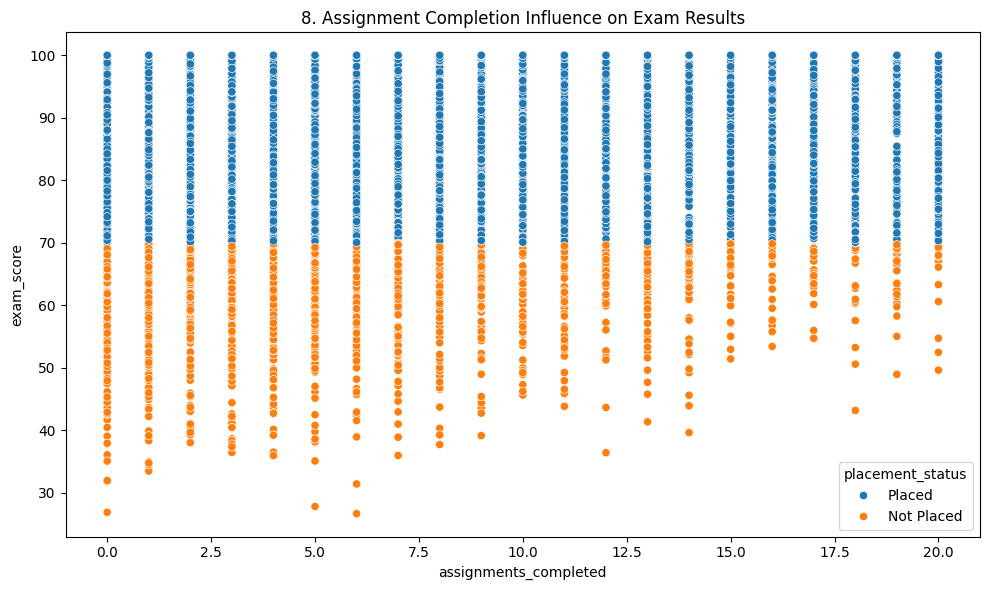

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='assignments_completed', y='exam_score', hue='placement_status', data=df)
plt.title(f'{plot_no}. Assignment Completion Influence on Exam Results')
show_fig()
plot_no += 1

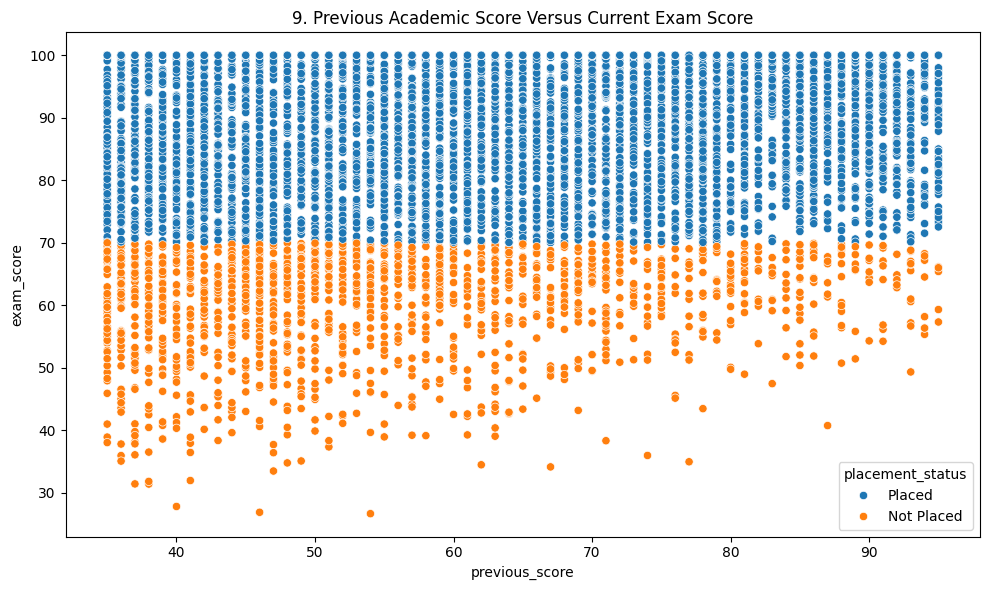

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='previous_score', y='exam_score', hue='placement_status', data=df)
plt.title(f'{plot_no}. Previous Academic Score Versus Current Exam Score')
show_fig()
plot_no += 1

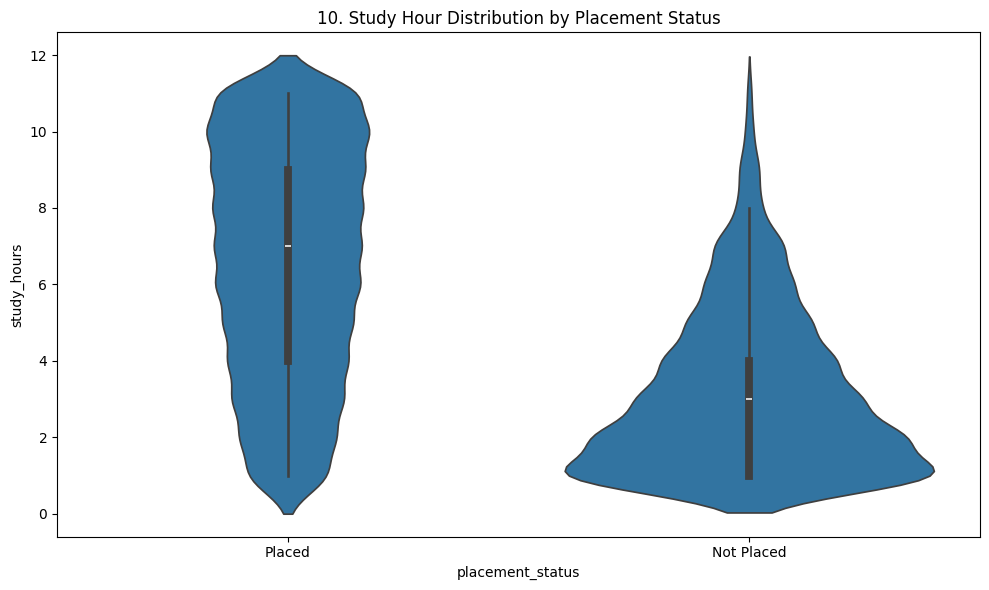

In [22]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='placement_status', y='study_hours', data=df)
plt.title(f'{plot_no}. Study Hour Distribution by Placement Status')
show_fig()
plot_no += 1

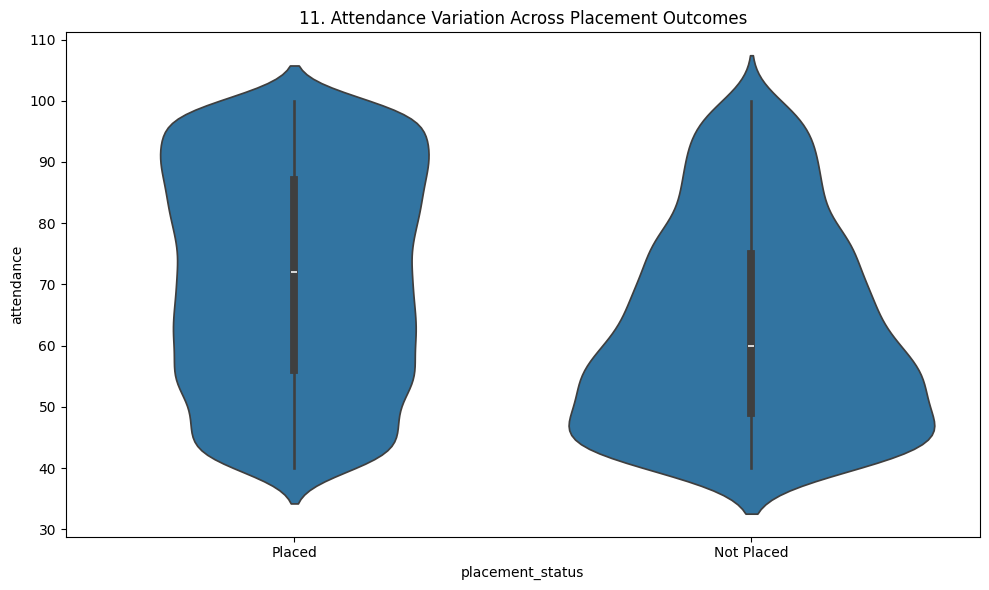

In [23]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='placement_status', y='attendance', data=df)
plt.title(f'{plot_no}. Attendance Variation Across Placement Outcomes')
show_fig()
plot_no += 1

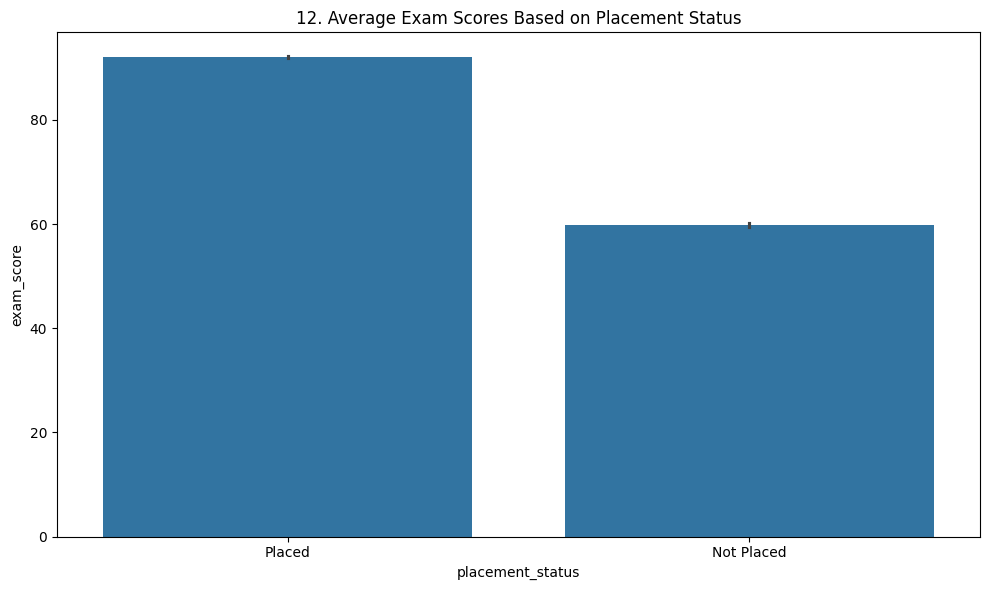

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='placement_status', y='exam_score', data=df)
plt.title(f'{plot_no}. Average Exam Scores Based on Placement Status')
show_fig()
plot_no += 1

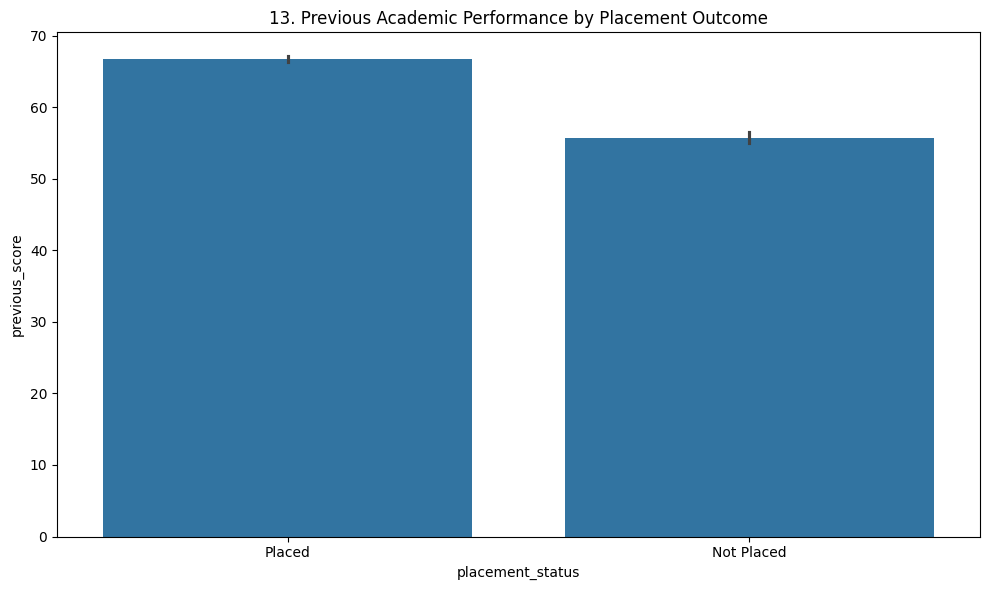

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='placement_status', y='previous_score', data=df)
plt.title(f'{plot_no}. Previous Academic Performance by Placement Outcome')
show_fig()
plot_no += 1

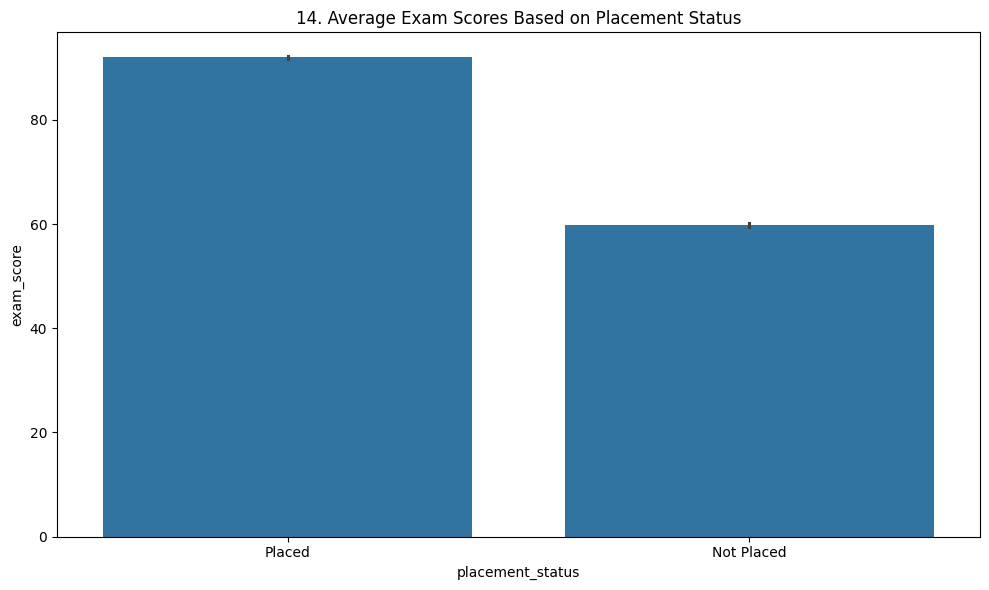

In [26]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='placement_status', y='exam_score', data=df)
plt.title(f'{plot_no}. Average Exam Scores Based on Placement Status')
show_fig()
plot_no += 1

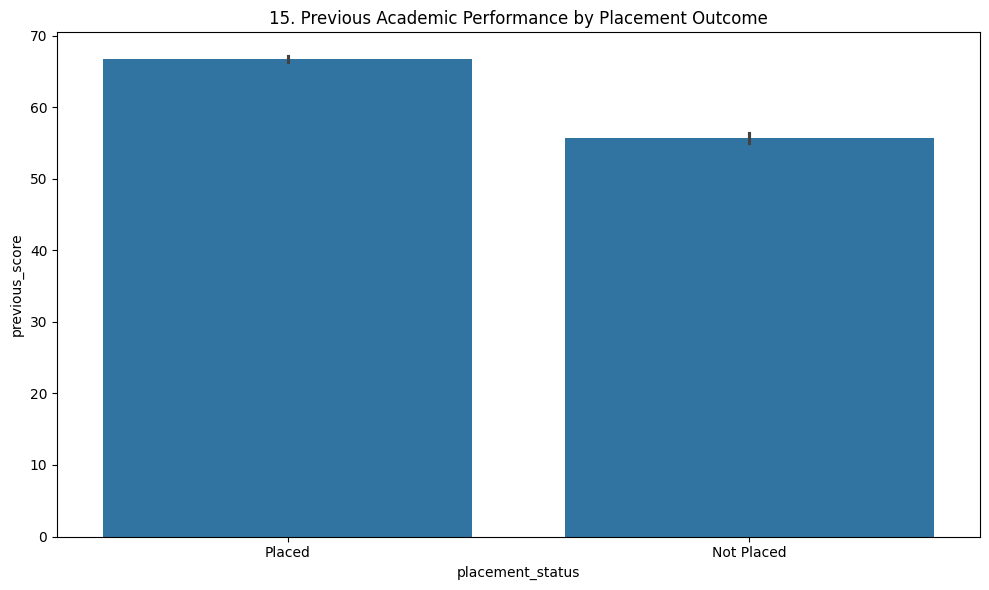

In [27]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='placement_status', y='previous_score', data=df)
plt.title(f'{plot_no}. Previous Academic Performance by Placement Outcome')
show_fig()
plot_no += 1

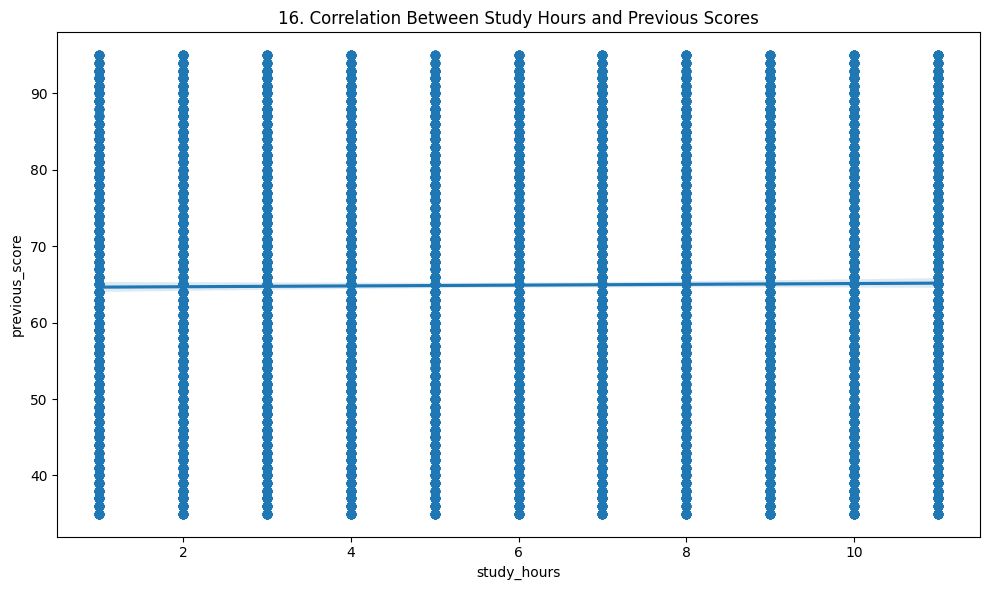

In [28]:
fig = plt.figure(figsize=(10,6))
sns.regplot(x='study_hours', y='previous_score', data=df)
plt.title(f'{plot_no}. Correlation Between Study Hours and Previous Scores')
show_fig()
plot_no += 1

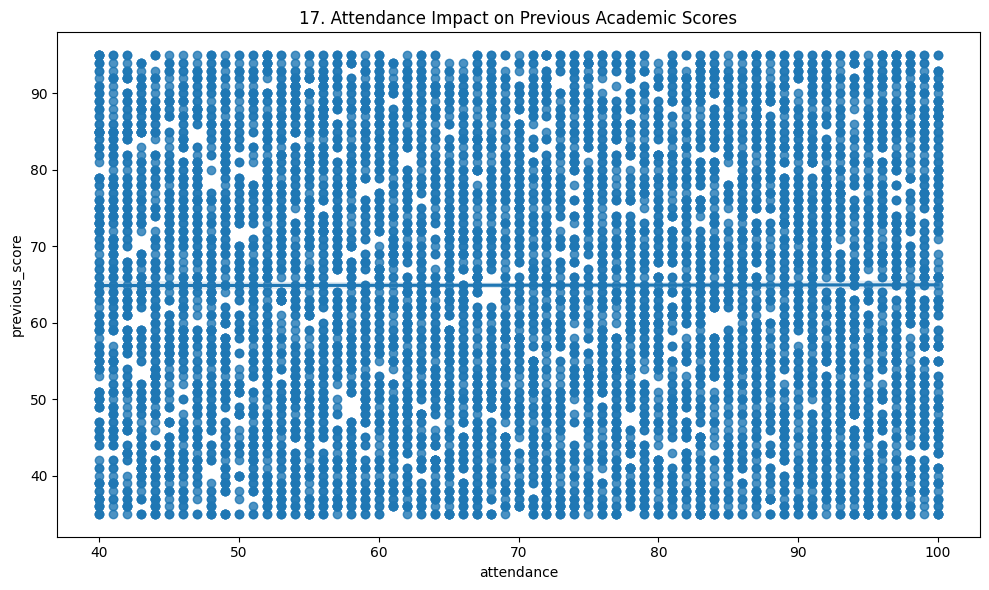

In [29]:
fig = plt.figure(figsize=(10,6))
sns.regplot(x='attendance', y='previous_score', data=df)
plt.title(f'{plot_no}. Attendance Impact on Previous Academic Scores')
show_fig()
plot_no += 1

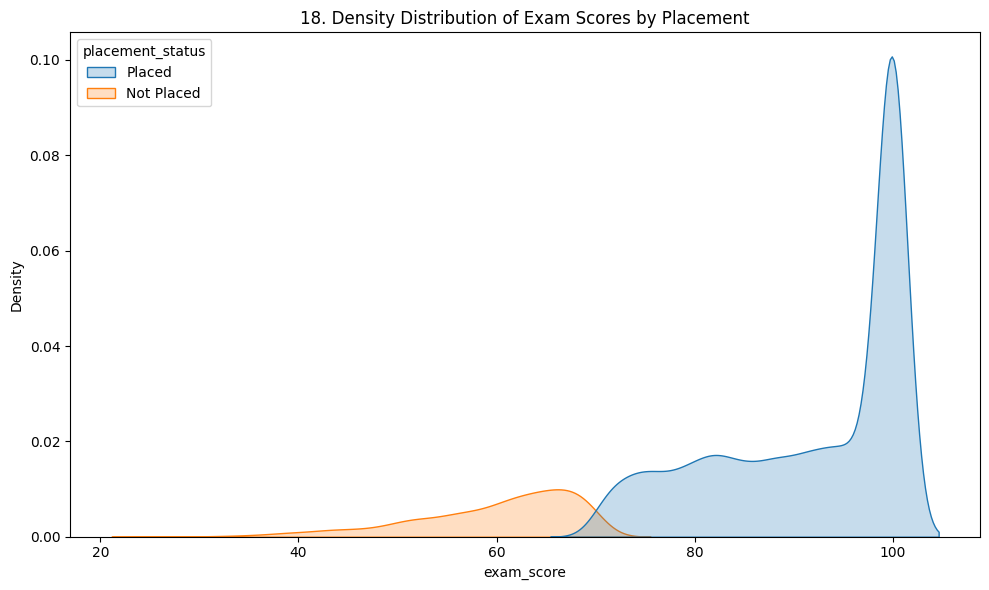

In [30]:
fig = plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='exam_score', hue='placement_status', fill=True)
plt.title(f'{plot_no}. Density Distribution of Exam Scores by Placement')
show_fig()
plot_no += 1

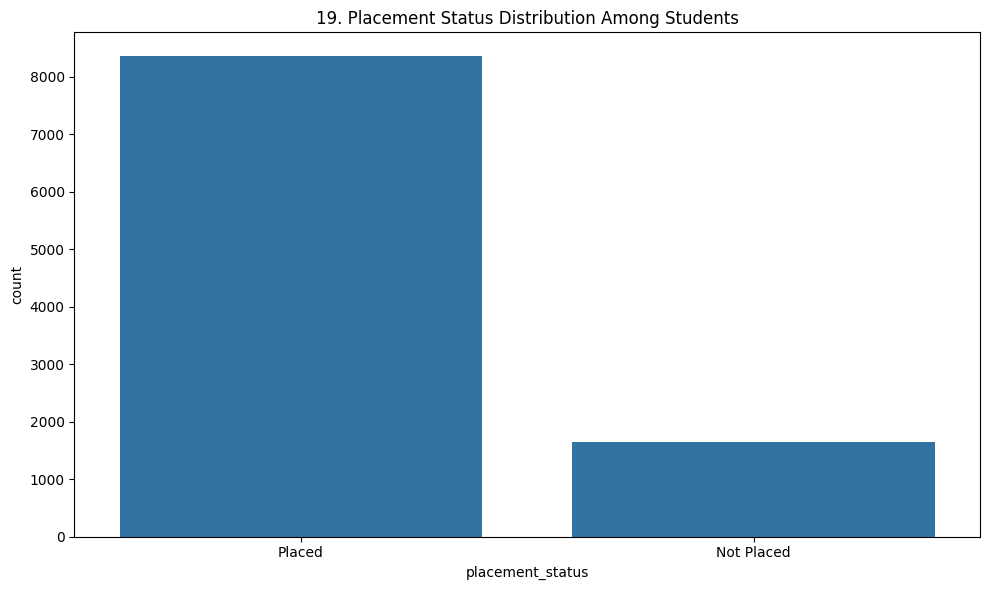

In [31]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='placement_status', data=df)
plt.title(f'{plot_no}. Placement Status Distribution Among Students')
show_fig()
plot_no += 1

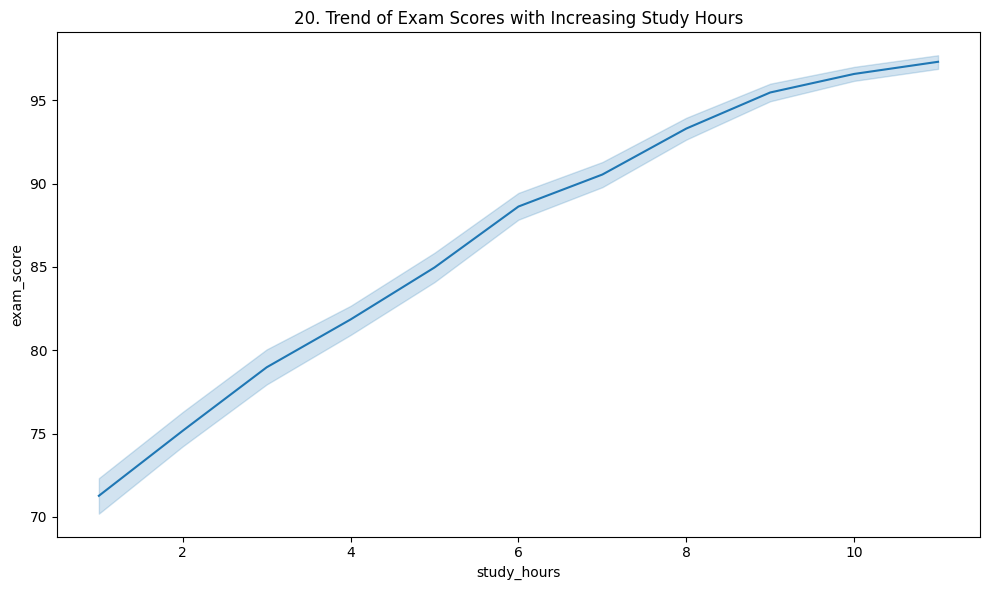

In [32]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x=df.sort_values('study_hours')['study_hours'], y=df.sort_values('study_hours')['exam_score'])
plt.title(f'{plot_no}. Trend of Exam Scores with Increasing Study Hours')
show_fig()
plot_no += 1

<Figure size 1000x600 with 0 Axes>

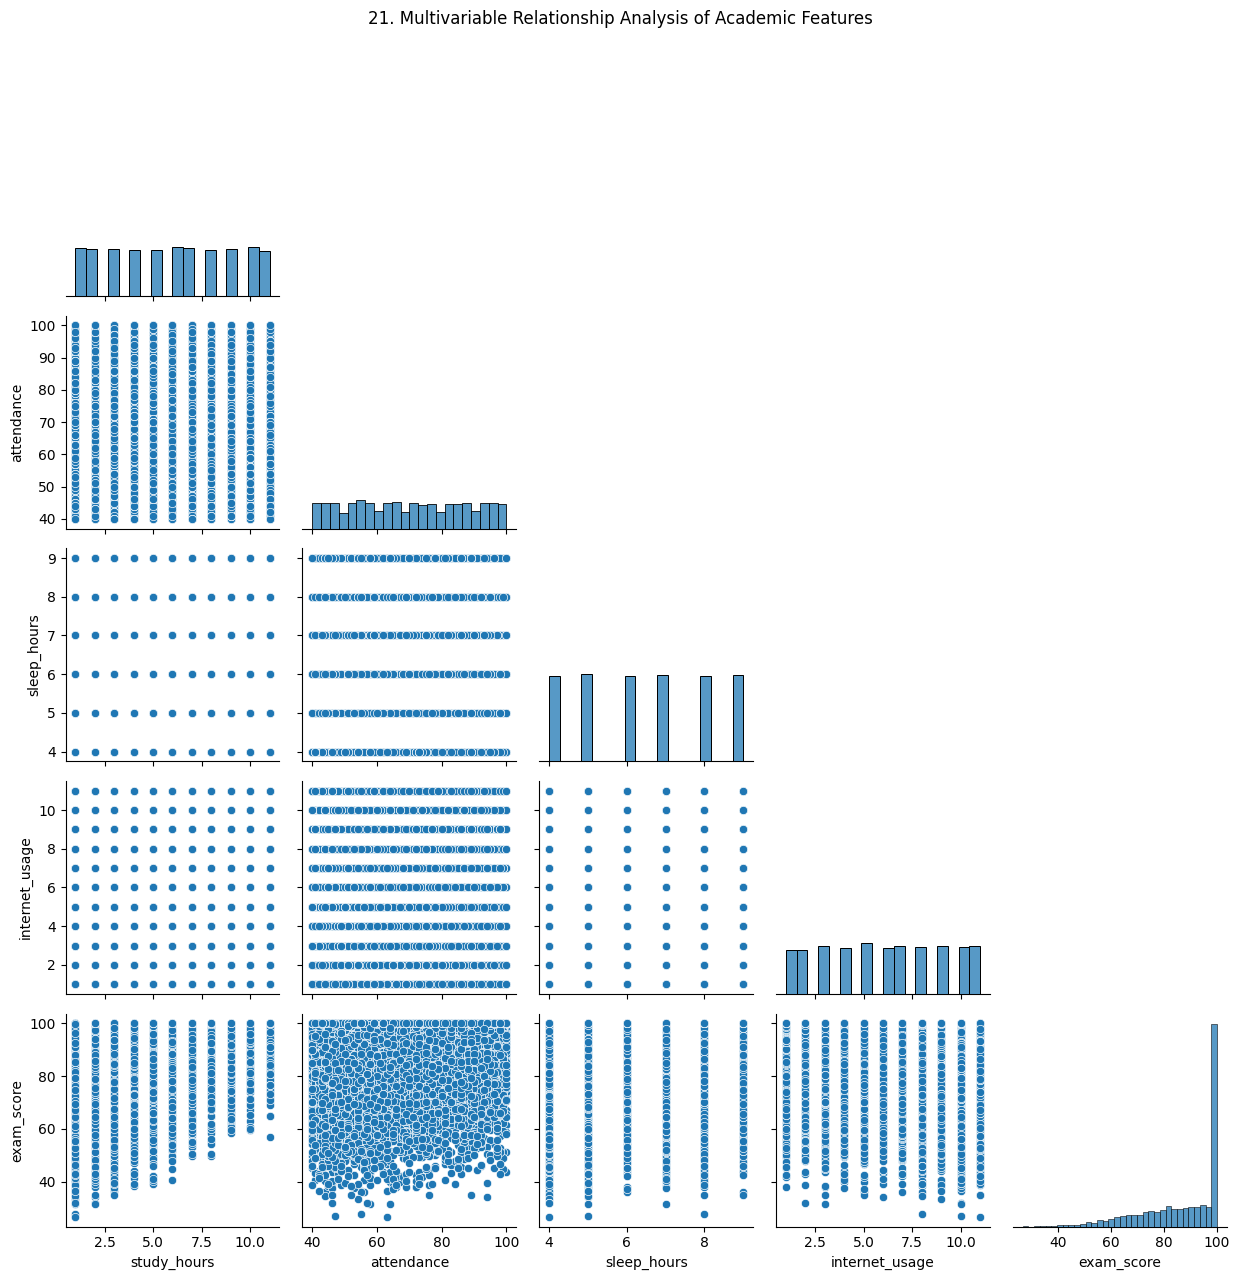

In [33]:
fig = plt.figure(figsize=(10,6))
sns.pairplot(df[['study_hours','attendance','sleep_hours','internet_usage','exam_score']], corner=True)
plt.suptitle(f'{plot_no}. Multivariable Relationship Analysis of Academic Features', y=1.02)
show_fig()
plot_no += 1

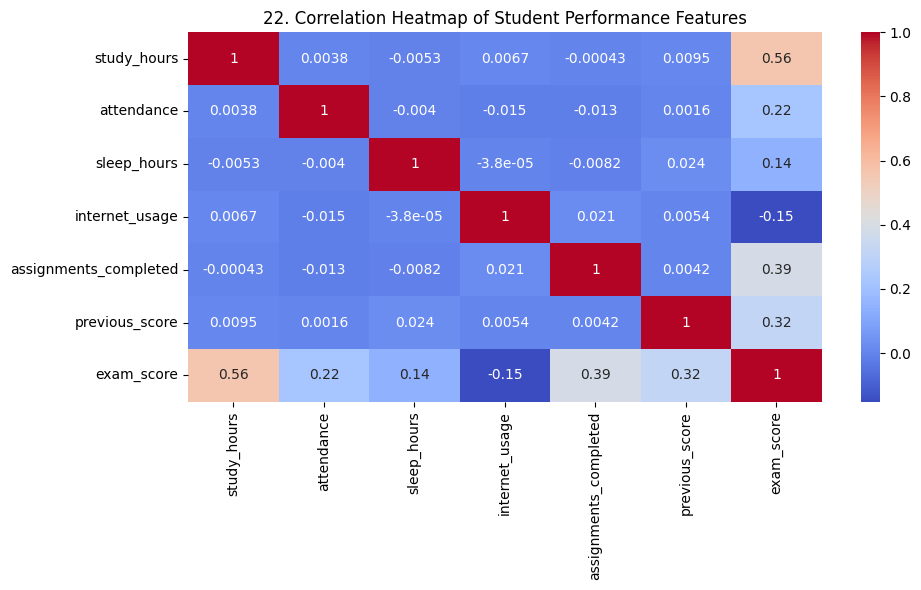

In [34]:
corr = df.corr(numeric_only=True)

fig = plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Student Performance Features')
show_fig()
plot_no += 1

# Model Training

## select features and target

In [35]:
X = df[['study_hours', 'attendance', 'sleep_hours', 'internet_usage', 'assignments_completed', 'previous_score']]
y = df['exam_score']

## split dataset

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## scale the features

In [37]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## train powerful supervised model

In [38]:
model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
model.fit(X_train_scaled, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,300
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


## predict exam scores

In [39]:
y_pred = model.predict(X_test_scaled)

## calculate accuracy metrics

In [40]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
accuracy = r2_score(y_test, y_pred)

## print model performance

In [41]:
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("Model Accuracy R2 Score:", accuracy)

Mean Absolute Error: 5.72145921978148
Root Mean Squared Error: 7.915199368144356
Model Accuracy R2 Score: 0.7272977244242385


## create actual vs predicted visualization

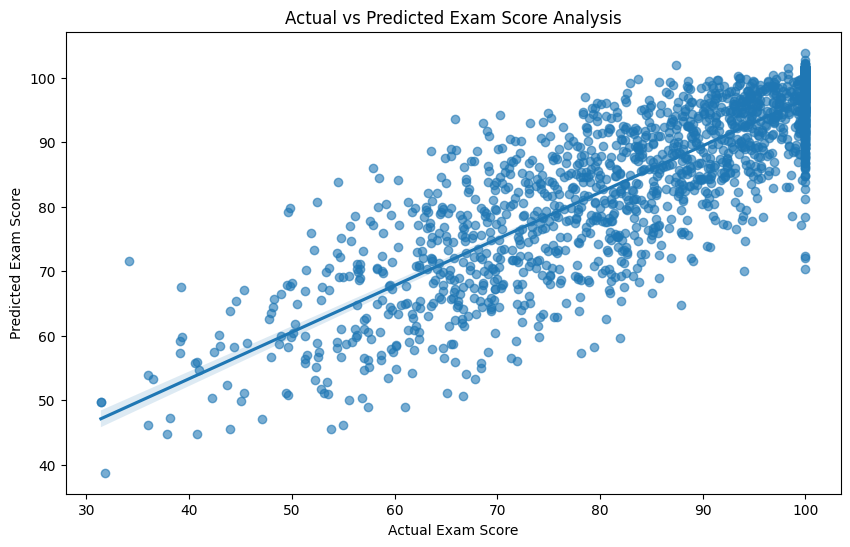

In [42]:
fig = plt.figure(figsize=(10,6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.6})
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Score Analysis")
plt.show()